<h1 style="text-align: center; font-family: 'Roboto', sans-serif; 
font-weight: bold; font-size: 36px; color: #2c3e50;">
Rapport de Synthese - Prediction de l'Attrition RH</h1>
<h3 style="text-align: center; color: #7f8c8d;">
HumanForYou - Secteur Pharmaceutique Indien</h3>
<p style="text-align: center; color: #95a5a6; font-size: 13px;">
Analyse de l'attrition (~4 400 employes, donnees 2015-2016) et modele predictif 
pour identifier les employes susceptibles de quitter l'entreprise.</p>

> **A destination des decideurs RH.** Ce document presente les conclusions 
principales, les facteurs identifies et les performances du modele retenu. 
Pour les details methodologiques, se referer aux notebooks 01 a 05.

---
## **0. Chargement des dependances**

In [10]:
import warnings
warnings.filterwarnings('ignore')

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc,
)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

# Constantes partagees avec 05_modeling.ipynb
RANDOM_STATE   = 42
TEST_SIZE      = 0.2
TARGET_COL     = 'has_left'
COLS_TO_DROP   = ['overtime_ratio', 'percent_salary_hike', 'years_with_curr_manager']
DATA_PATH      = '../data/processed/merged_data.csv'
MODEL_PATH     = '../data/processed/best_model.pkl'
RESULTS_PATH   = '../data/processed/model_results.csv'

PALETTE = {0: '#4C72B0', 1: '#DD8452'}
LABELS  = {0: 'En poste', 1: 'Depart'}

# Verification des fichiers requis
for path in [DATA_PATH, MODEL_PATH, RESULTS_PATH]:
    status = "[OK]" if os.path.exists(path) else "[MANQUANT - executer 05_modeling.ipynb]"
    print(f"{status}  {path}")


[OK]  ../data/processed/merged_data.csv
[OK]  ../data/processed/best_model.pkl
[OK]  ../data/processed/model_results.csv


---
## **1. Contexte & Description du Dataset**

HumanForYou est une entreprise pharmaceutique indienne d'environ 4 400 employes. 
En 2016, elle observe un taux d'attrition annuel d'environ **15 %**, soit ~660 departs.


Les couts associes a l'attrition incluent le recrutement, la formation et la perte de 
competences. Un modele predictif permet d'identifier en amont les profils a risque 
et de cibler les actions de retention.

Employes analyses  : 4,410
Departs observes   : 711 (16.1%)
Variables disponibles : 24
Periode              : 2015 (badges) - 2016 (departs)


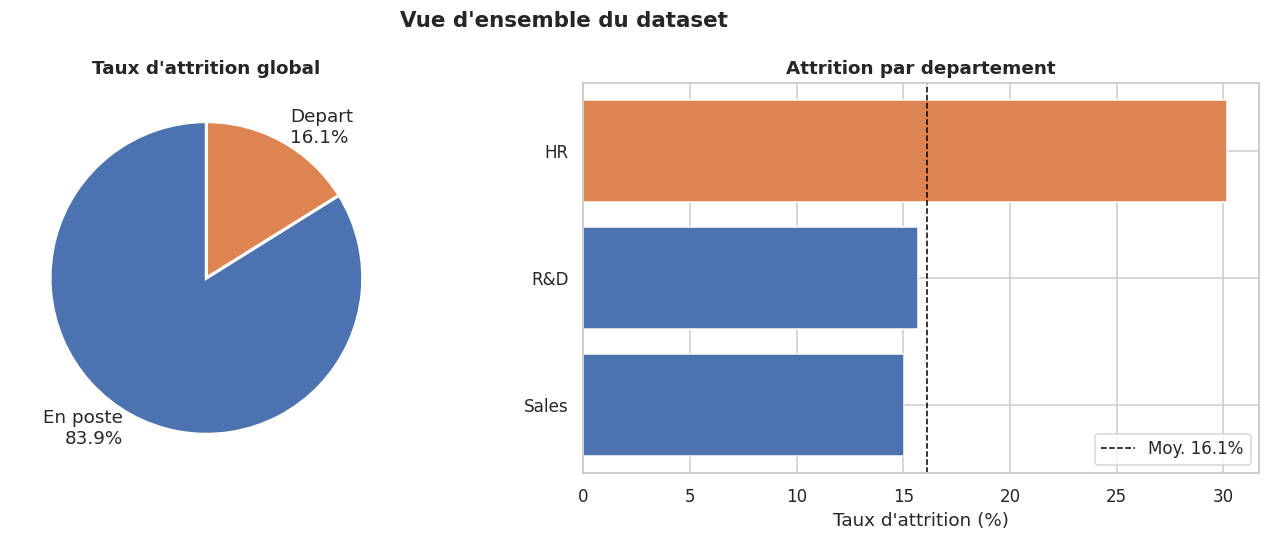

In [11]:
df = pd.read_csv(DATA_PATH)

n_total = len(df)
n_left  = int(df[TARGET_COL].sum())
rate    = n_left / n_total

print(f"Employes analyses  : {n_total:,}")
print(f"Departs observes   : {n_left:,} ({rate:.1%})")
print(f"Variables disponibles : {df.shape[1]}")
print(f"Periode              : 2015 (badges) - 2016 (departs)")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Vue d'ensemble du dataset", fontsize=14, fontweight='bold')

# Pie chart attrition
counts = df[TARGET_COL].value_counts().sort_index()
pcts   = counts / counts.sum() * 100
axes[0].pie(
    counts.values,
    labels=[f"{LABELS[k]}\n{pcts[k]:.1f}%" for k in counts.index],
    colors=[PALETTE[k] for k in counts.index],
    startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=2),
    textprops={'fontsize': 12},
)
axes[0].set_title("Taux d'attrition global", fontweight='bold')

# Repartition par departement
dept_counts = df.groupby('department')[TARGET_COL].agg(['sum', 'count'])
dept_counts['rate'] = dept_counts['sum'] / dept_counts['count'] * 100
dept_counts = dept_counts.sort_values('rate', ascending=True)
colors_dept = [PALETTE[1] if r > rate * 100 else PALETTE[0] for r in dept_counts['rate']]
axes[1].barh(dept_counts.index, dept_counts['rate'], color=colors_dept, edgecolor='white')
axes[1].axvline(rate * 100, color='black', linewidth=1, linestyle='--',
                label=f"Moy. {rate*100:.1f}%")
axes[1].set_xlabel("Taux d'attrition (%)")
axes[1].set_title("Attrition par departement", fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()


---
## **2. Profil de l'Employe a Risque**

L'analyse exploratoire a permis d'identifier les signaux les plus discriminants. 
Le profil synthetique d'un employe susceptible de partir est le suivant :

| Dimension | Signal detecte |
|---|---|
| **Role & departement** | Sales Executive & Lab Technician dans Sales / HR sur-representes |
| **Niveau hierarchique** | Niveaux bas (1-2) partent davantage |
| **Salaire** | Salaire median plus faible chez les partants |
| **Anciennete** | Moins d'annees dans l'entreprise et d'experience totale |
| **Promotion** | Stagnation plus marquee (plus d'annees sans promotion) |
| **Voyages** | Deplacements frequents -> taux d'attrition plus eleve |
| **Heures sup.** | Taux d'heures supplementaires nettement plus eleve |
| **Satisfaction** | Scores plus faibles sur job, environnement, equilibre vie pro/perso |

**Profil typique :** employe junior, faiblement remunere, peu de perspectives de promotion, 
voyageant frequemment, avec de nombreuses heures supplementaires et une satisfaction degradee.

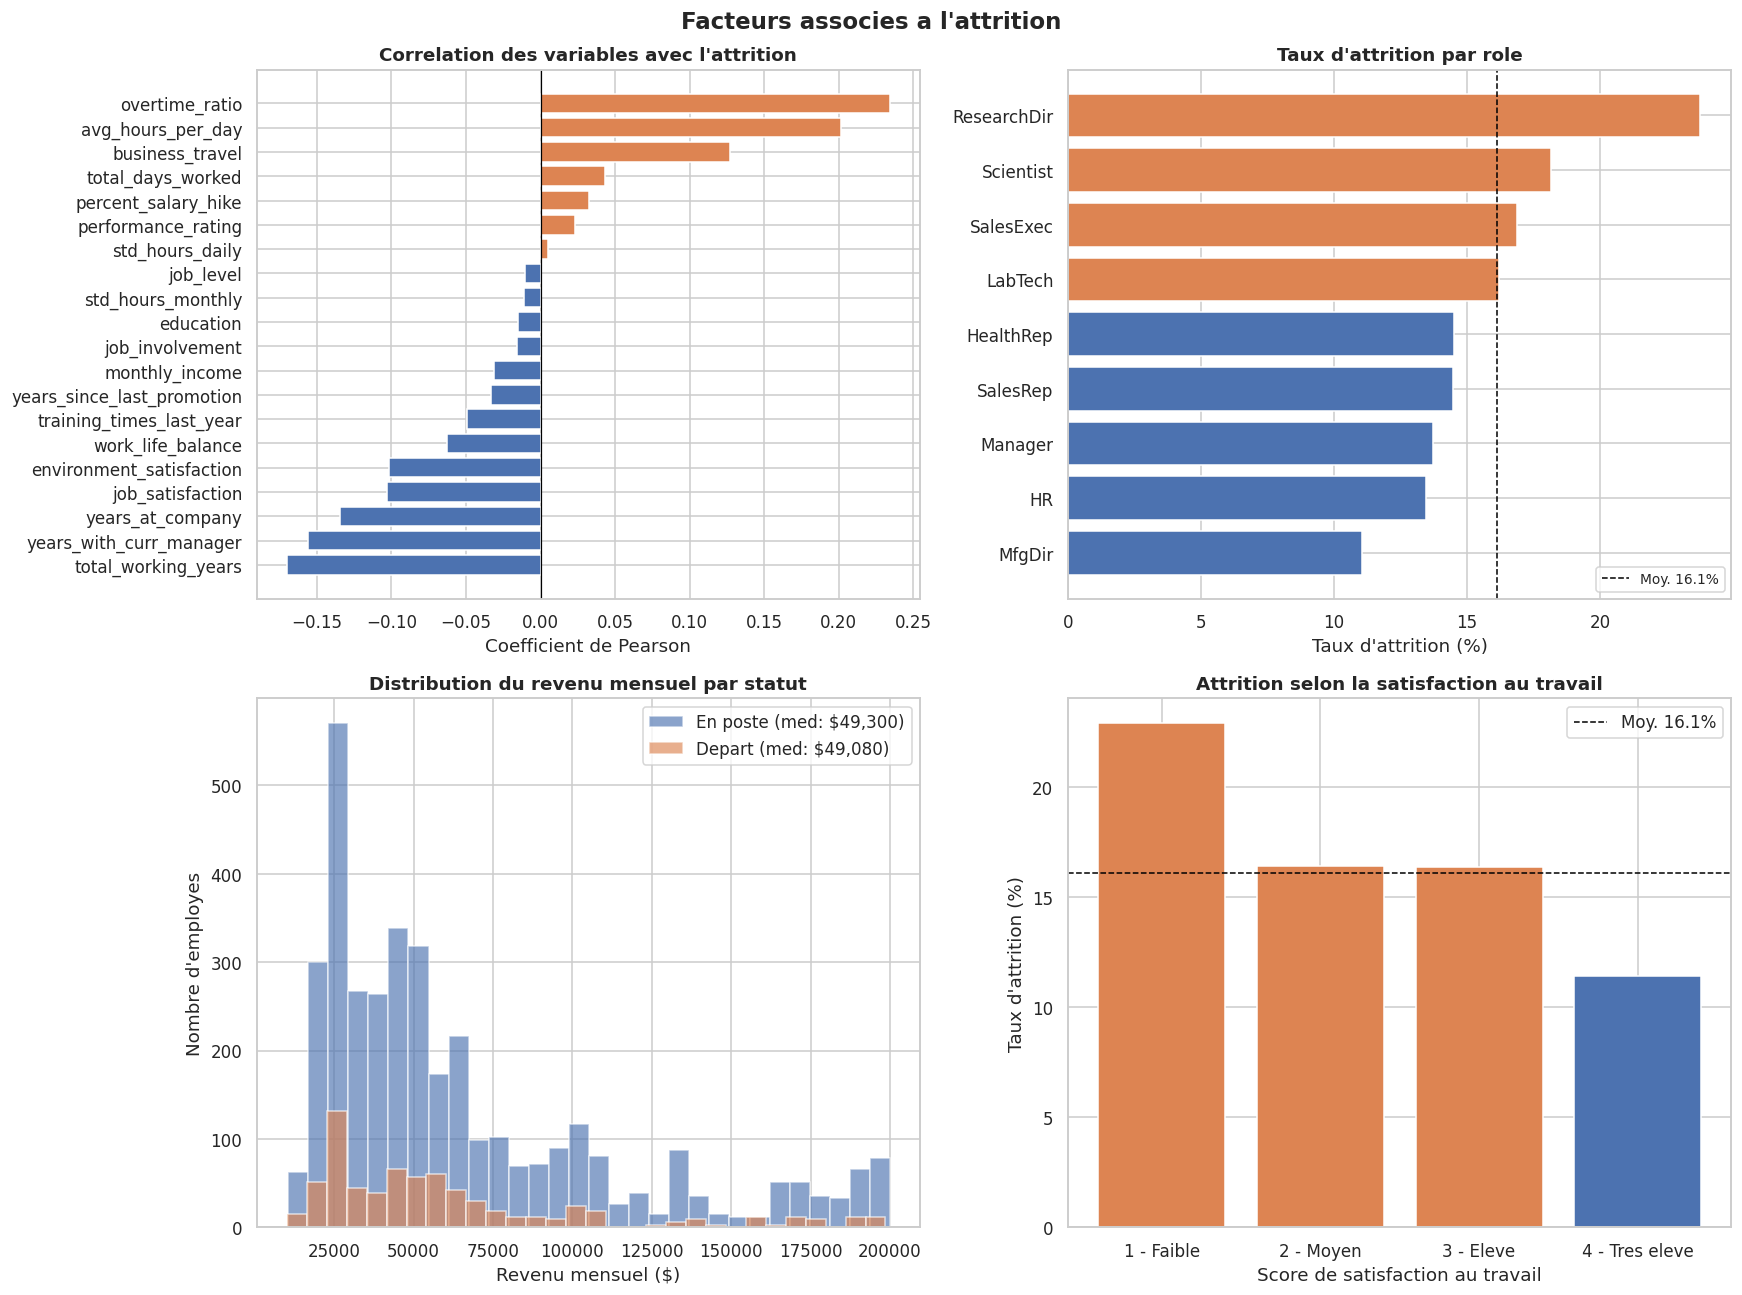

In [12]:
mean_rate = df[TARGET_COL].mean() * 100

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Facteurs associes a l'attrition", fontsize=15, fontweight='bold')

# --- Plot 1 : Correlation avec la cible ---
num_cols = df.select_dtypes(include='number').columns.tolist()
corr = df[num_cols].corr()[TARGET_COL].drop(TARGET_COL).sort_values()
colors_corr = [PALETTE[1] if v > 0 else PALETTE[0] for v in corr.values]
axes[0, 0].barh(corr.index, corr.values, color=colors_corr, edgecolor='white')
axes[0, 0].axvline(0, color='black', linewidth=0.8)
axes[0, 0].set_title('Correlation des variables avec l\'attrition', fontweight='bold')
axes[0, 0].set_xlabel('Coefficient de Pearson')

# --- Plot 2 : Attrition par role ---
rates_role = (df.groupby('job_role')[TARGET_COL]
              .agg(['sum', 'count'])
              .assign(rate=lambda x: x['sum'] / x['count'] * 100)
              .sort_values('rate', ascending=True))
colors_role = [PALETTE[1] if r > mean_rate else PALETTE[0] for r in rates_role['rate']]
axes[0, 1].barh(rates_role.index, rates_role['rate'], color=colors_role, edgecolor='white')
axes[0, 1].axvline(mean_rate, color='black', linewidth=1, linestyle='--',
                   label=f"Moy. {mean_rate:.1f}%")
axes[0, 1].set_title('Taux d\'attrition par role', fontweight='bold')
axes[0, 1].set_xlabel('Taux d\'attrition (%)')
axes[0, 1].legend(fontsize=9)

# --- Plot 3 : Revenu mensuel ---
for status, label in [(0, 'En poste'), (1, 'Depart')]:
    subset = df[df[TARGET_COL] == status]['monthly_income']
    axes[1, 0].hist(subset, bins=30, alpha=0.65,
                    label=f'{label} (med: ${subset.median():,.0f})',
                    color=PALETTE[status], edgecolor='white')
axes[1, 0].set_xlabel('Revenu mensuel ($)')
axes[1, 0].set_ylabel('Nombre d\'employes')
axes[1, 0].set_title('Distribution du revenu mensuel par statut', fontweight='bold')
axes[1, 0].legend()

# --- Plot 4 : Satisfaction au travail ---
sat_map = {1: '1 - Faible', 2: '2 - Moyen', 3: '3 - Eleve', 4: '4 - Tres eleve'}
sat_rates = (df.groupby('job_satisfaction')[TARGET_COL]
             .agg(['sum', 'count'])
             .assign(rate=lambda x: x['sum'] / x['count'] * 100))
sat_rates.index = [sat_map.get(i, str(i)) for i in sat_rates.index]
colors_sat = [PALETTE[1] if r > mean_rate else PALETTE[0] for r in sat_rates['rate']]
axes[1, 1].bar(sat_rates.index, sat_rates['rate'], color=colors_sat, edgecolor='white')
axes[1, 1].axhline(mean_rate, color='black', linewidth=1, linestyle='--',
                   label=f"Moy. {mean_rate:.1f}%")
axes[1, 1].set_xlabel('Score de satisfaction au travail')
axes[1, 1].set_ylabel('Taux d\'attrition (%)')
axes[1, 1].set_title('Attrition selon la satisfaction au travail', fontweight='bold')
axes[1, 1].legend()

plt.tight_layout()
plt.show()


---
## **3. Demarche de Modelisation**

### Modeles evalues et resultats

Cinq classifieurs classiques et un reseau de neurones ont ete compares dans des conditions 
identiques (meme split 80/20 stratifie, validation croisee 5 folds, optimisation sur ROC-AUC).

| Modele | ROC-AUC (CV) | ROC-AUC (test) | F1 (test) | Recall (test) |
|---|:---:|:---:|:---:|:---:|
| **ExtraTrees** | 0.992 | 0.999 | **0.989** | 0.979 |
| GradientBoosting | 0.967 | 0.991 | 0.952 | 0.908 |
| RandomForest | 0.978 | 0.994 | 0.855 | 0.746 |
| SVC | 0.932 | 0.977 | - | - |
| LogisticRegression | 0.778 | 0.780 | 0.479 | 0.732 |
| MLP (reseau de neurones) | - | - | < ExtraTrees | - |

### Modele retenu : ExtraTrees

ExtraTrees est selectionne sur la base du **F1-Score** (0.989), qui equilibre le recall 
(ne pas manquer de departs) et la precision (ne pas alerter inutilement).

Un diagnostic de leakage a ete realise : les ecarts CV/Test sont tous inferieurs a 0.025 
et aucune variable ne domine les importances (max 8.75%). Les hautes performances 
s'expliquent par la nature **synthetique** du dataset IBM Watson, concu avec des patterns 
deliberement propres. Une validation sur donnees RH reelles serait requise avant deploiement.

### Pourquoi le MLP est exclu

Sur un dataset tabulaire de ~4 400 lignes, le MLP ne dispose pas d'un biais inductif utile. 
De plus, son opacite est incompatible avec les exigences de transparence de l'EU AI Act 
(Art. 13 & 14) pour un systeme RH classe a haut risque.

### Metrique de selection

Le **F1-Score** equilibre recall et precision sur la classe minoritaire (~15% de departs). 
Le **ROC-AUC** optimise les hyperparametres en validation croisee (independant du seuil).


---
## **4. Comparaison des Modeles**

Les resultats ci-dessous sont issus de l'evaluation sur le jeu de test (20 % des donnees). 
La meilleure valeur de chaque colonne est mise en evidence.

In [13]:
# Chargement des resultats sauvegardes par 05_modeling.ipynb
results_df = pd.read_csv(RESULTS_PATH, index_col='modele')

display_cols = {
    'recall'      : 'Recall',
    'precision'   : 'Precision',
    'f1'          : 'F1-Score',
    'roc_auc'     : 'ROC-AUC',
    'cv_roc_auc'  : 'CV ROC-AUC',
    'train_time_s': 'Temps train (s)',
    'predict_ms'  : 'Temps pred. (ms)',
}
table = results_df[list(display_cols.keys())].rename(columns=display_cols)

def highlight_best(s):
    if s.name in ['Temps train (s)', 'Temps pred. (ms)']:
        best = s.min()
        return ['background-color: #c8e6c9; font-weight: bold' if v == best else '' for v in s]
    best = s.max()
    return ['background-color: #ffccbc; font-weight: bold' if v == best else '' for v in s]

styled = (
    table.style
    .apply(highlight_best)
    .format({
        'Recall'        : '{:.3f}',
        'Precision'     : '{:.3f}',
        'F1-Score'      : '{:.3f}',
        'ROC-AUC'       : '{:.3f}',
        'CV ROC-AUC'    : '{:.3f}',
        'Temps train (s)': '{:.1f}s',
        'Temps pred. (ms)': '{:.2f}ms',
    })
    .set_caption('Comparaison des modeles - meilleure valeur en evidence')
    .set_table_styles([{'selector': 'caption', 'props': 'caption-side: top; font-size: 13px; font-weight: bold;'}])
)

best_model_name = results_df['f1'].idxmax()
print(f"Meilleur modele (F1-Score) : {best_model_name}")
display(styled)


Meilleur modele (F1-Score) : ExtraTrees


,Recall,Precision,F1-Score,ROC-AUC,CV ROC-AUC,Temps train (s),Temps pred. (ms)
modele,,,,,,,
LogisticRegression,0.732,0.356,0.479,0.780,0.778,38.5s,8.11ms
RandomForest,0.746,1.000,0.855,0.994,0.978,35.4s,216.98ms
ExtraTrees,0.979,1.000,0.989,0.999,0.992,13.2s,222.72ms
GradientBoosting,0.908,1.000,0.952,0.991,0.967,37.7s,17.18ms
SVC,0.810,0.958,0.878,0.977,0.931,11.4s,107.72ms
MLP (réseau de neurones),0.000,0.000,0.000,0.602,0.859,5.8s,8.78ms


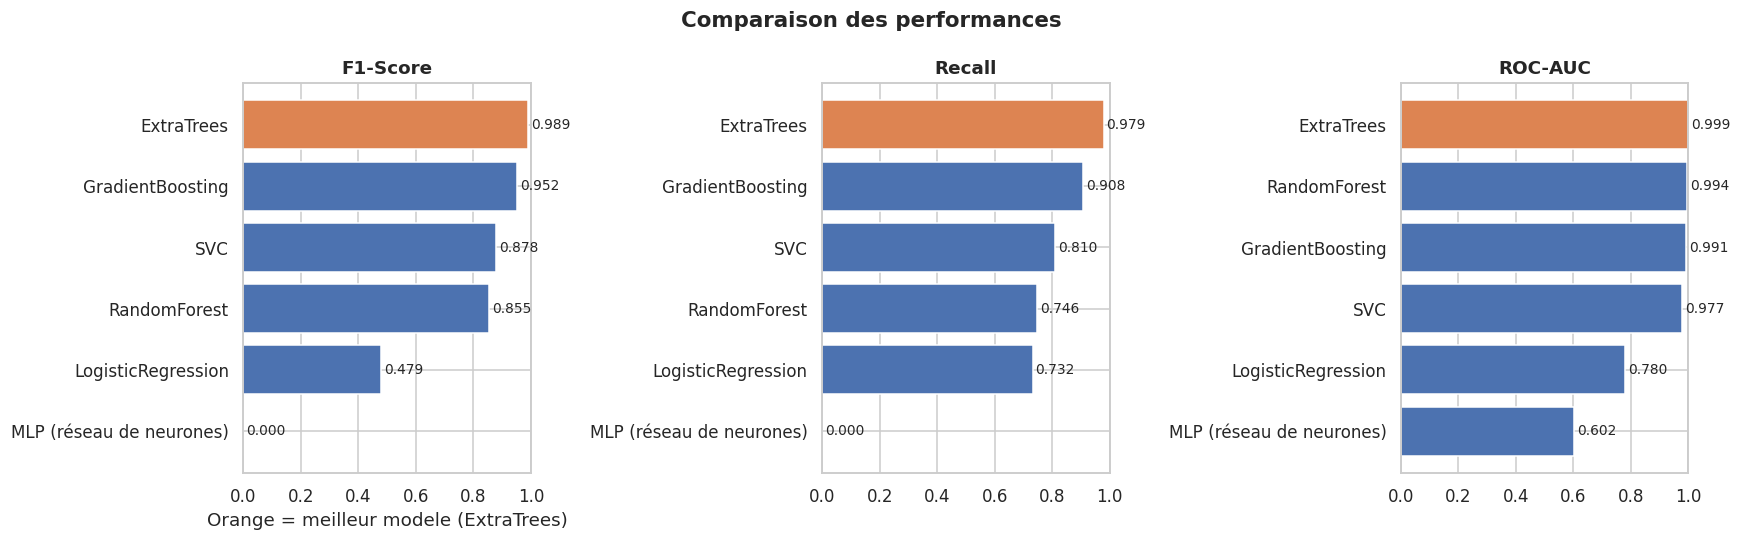

In [14]:
# Graphique comparatif des metriques cles
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Comparaison des performances", fontsize=14, fontweight='bold')

metrics = [('f1', 'F1-Score'), ('recall', 'Recall'), ('roc_auc', 'ROC-AUC')]
palette = sns.color_palette('muted', n_colors=len(results_df))

for ax, (col, label) in zip(axes, metrics):
    vals = results_df[col].sort_values(ascending=True)
    colors = ['#DD8452' if idx == best_model_name else '#4C72B0' for idx in vals.index]
    ax.barh(vals.index, vals.values, color=colors, edgecolor='white')
    ax.set_xlim(0, 1)
    ax.set_title(label, fontweight='bold')
    for i, (v, idx) in enumerate(zip(vals.values, vals.index)):
        ax.text(v + 0.01, i, f'{v:.3f}', va='center', fontsize=9)
    if col == 'f1':
        ax.set_xlabel(f"Orange = meilleur modele ({best_model_name})")

plt.tight_layout()
plt.show()


---
## **5. Performance du Meilleur Modele**

La **matrice de confusion** indique comment le modele classe les employes sur le jeu de test. 
La **courbe ROC** mesure sa capacite a distinguer les partants des non-partants 
quel que soit le seuil de decision.


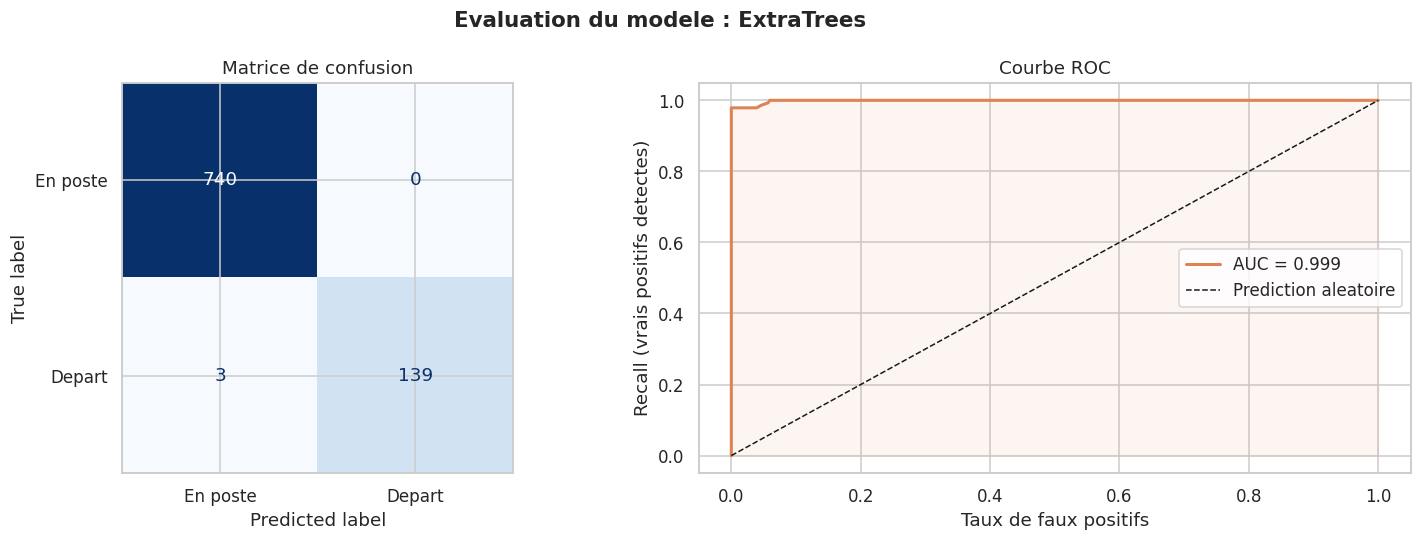

Sur 882 employes du jeu de test :
  Departs correctement identifies (vrais positifs) : 139
  Departs manques (faux negatifs)                  : 3
  Alertes incorrectes (faux positifs)              : 0
  En poste correctement identifies                 : 740


In [15]:
# Chargement du modele et reconstruction du jeu de test identique a 05_modeling.ipynb
best_model = joblib.load(MODEL_PATH)

X = df.drop(columns=[TARGET_COL] + COLS_TO_DROP)
y = df[TARGET_COL]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_STATE
)

with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    y_pred  = best_model.predict(X_test)
    y_proba = best_model.predict_proba(X_test)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f"Evaluation du modele : {best_model_name}", fontsize=14, fontweight='bold')

# Matrice de confusion
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['En poste', 'Depart'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Matrice de confusion')

# Courbe ROC
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc_val = auc(fpr, tpr)
axes[1].plot(fpr, tpr, color='#DD8452', lw=2, label=f'AUC = {roc_auc_val:.3f}')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1, label='Prediction aleatoire')
axes[1].fill_between(fpr, tpr, alpha=0.08, color='#DD8452')
axes[1].set_xlabel('Taux de faux positifs')
axes[1].set_ylabel('Recall (vrais positifs detectes)')
axes[1].set_title('Courbe ROC')
axes[1].legend()

plt.tight_layout()
plt.show()

# Resume texte
tn, fp, fn, tp = cm.ravel()
print(f"Sur {len(y_test)} employes du jeu de test :")
print(f"  Departs correctement identifies (vrais positifs) : {tp}")
print(f"  Departs manques (faux negatifs)                  : {fn}")
print(f"  Alertes incorrectes (faux positifs)              : {fp}")
print(f"  En poste correctement identifies                 : {tn}")


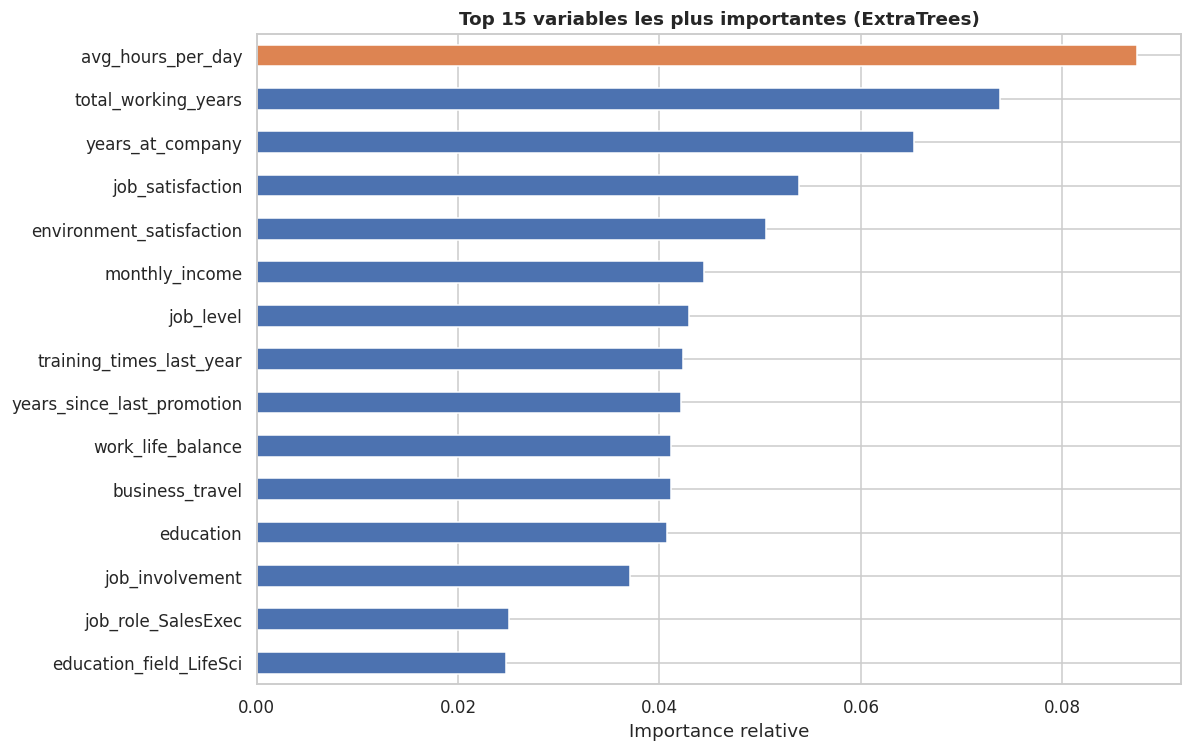

In [16]:
# Interpretabilite : variables les plus importantes pour le modele
clf          = best_model.named_steps['classifier']
preprocessor = best_model.named_steps['preprocessor']

numeric_features     = X.select_dtypes(include='number').columns.tolist()
categorical_features = X.select_dtypes(exclude='number').columns.tolist()

ohe          = preprocessor.named_transformers_['cat']
ohe_features = list(ohe.get_feature_names_out(categorical_features))
all_features = numeric_features + ohe_features

fig, ax = plt.subplots(figsize=(11, 7))

if hasattr(clf, 'feature_importances_'):
    importances = pd.Series(clf.feature_importances_, index=all_features)
    top15 = importances.sort_values(ascending=True).tail(15)
    colors_imp = ['#DD8452' if i == top15.idxmax() else '#4C72B0' for i in top15.index]
    top15.plot(kind='barh', ax=ax, color=colors_imp, edgecolor='white')
    ax.set_title(f'Top 15 variables les plus importantes ({best_model_name})', fontweight='bold')
    ax.set_xlabel('Importance relative')
elif hasattr(clf, 'coef_'):
    importances = pd.Series(np.abs(clf.coef_[0]), index=all_features)
    top15 = importances.sort_values(ascending=True).tail(15)
    colors_imp = ['#DD8452' if i == top15.idxmax() else '#4C72B0' for i in top15.index]
    top15.plot(kind='barh', ax=ax, color=colors_imp, edgecolor='white')
    ax.set_title(f'Top 15 variables (coefficients absolus) - {best_model_name}', fontweight='bold')
    ax.set_xlabel('|Coefficient|')
else:
    ax.text(0.5, 0.5, 'Ce modele ne fournit pas d\'importances de variables directement.',
            ha='center', va='center', transform=ax.transAxes, fontsize=12)

plt.tight_layout()
plt.show()


---
## **6. Recommandations RH**

Sur la base de l'analyse et des predictions du modele, voici les axes d'action prioritaires.

### 6.1 Actions a court terme

- **Heures supplementaires** : `avg_hours_per_day` est la variable la plus importante du modele 
(8.75% de l'importance totale) et la plus correlee avec le depart (+0.20). 
Mettre en place des alertes RH pour les employes depassant regulierement les horaires normaux.

- **Satisfaction au travail** : `job_satisfaction` et `environment_satisfaction` figurent dans 
le top 5 des variables. Des entretiens de suivi pour les employes avec des scores bas (1-2/4) 
permettraient d'intervenir avant la decision de depart.

### 6.2 Actions a moyen terme

- **Experience et anciennete** : `total_working_years` (-0.17) et `years_at_company` (-0.13) 
sont negativement correles avec le depart. Les profils juniors avec peu d'anciennete sont 
sur-representes parmi les partants. Un programme de progression interne pour les niveaux 1-2 
reduirait l'attrition sur ces profils.

- **Equilibre vie pro/perso** : `work_life_balance` figure dans le top 10 des variables. 
Revoir la politique de deplacement pour les roles a fort taux d'attrition (Sales Executive).

### 6.3 Utilisation du modele

Le modele genere une **liste d'employes a risque** que les RH peuvent qualifier avec leur 
connaissance du terrain. Il ne doit pas remplacer le jugement humain ni decider 
automatiquement d'une action sur un employe.

**Rappel important :** les performances du modele (F1=0.989) ont ete mesurees sur un dataset 
synthetique. Une validation sur les donnees RH reelles de l'entreprise est necessaire avant 
tout deploiement operationnel.


---
## **7. Cadre Ethique & Conformite**

### EU AI Act - Systeme a haut risque (Annexe III)

Tout systeme d'IA utilise pour des decisions RH est classe a haut risque. 
Trois obligations s'appliquent directement :

- **Art. 10 - Qualite des donnees** : le dataset utilise est synthetique (IBM Watson). 
Il ne peut pas etre considere comme representatif de la population cible sans validation 
complementaire. Un deploiement base uniquement sur ces donnees ne serait pas conforme.

- **Art. 13 - Transparence** : ExtraTrees avec `max_depth=None` contient des arbres tres 
profonds. Les feature importances globales (top variable : heures supplementaires, 8.75%) 
donnent une vue agregee, mais l'explication d'une prediction individuelle reste difficile. 
Un modele plus interpretable (regression logistique) peut etre preferable selon le contexte.

- **Art. 14 - Supervision humaine** : le modele est un outil d'aide a la decision. 
Toute action sur un employe reste a la discretion du responsable RH, jamais du modele seul.

### RGPD Art. 22 - Droit a l'explication

Les employes identifies comme a risque ont le droit d'etre informes de l'existence du systeme 
et d'obtenir une explication de la prediction les concernant. 
Cela implique de documenter les variables utilisees et leur influence.

### Equite algorithmique

Les top variables (`avg_hours_per_day`, `total_working_years`, `job_satisfaction`) sont des 
indicateurs metier legitimes. Aucune variable protegee directe n'est utilisee.

Cependant, `job_role` et `department` peuvent constituer des **proxies indirects** si ces 
categories sont correlees avec des caracteristiques demographiques dans la population reelle. 
Il est recommande de calculer le recall par sous-groupe (departement, role, niveau) avant 
deploiement pour s'assurer que les recommandations de retention sont equitablement distribuees.
